# Condition C — Fine-tuned CLIP, Crops Only

- All images are bbox cropped throughout
- Fine-tune CLIP vision encoder (last 4 blocks) with SupCon loss
- Evaluate with crop embeddings fused with BLIP crop captions

In [1]:
!pip install git+https://github.com/openai/CLIP.git -q
!pip install faiss-cpu -q
print('Done.')

import os, json, math, random, zipfile
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
import faiss
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Sampler
from collections import defaultdict
from IPython.display import FileLink

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 75.8 MB/s eta 0:00:00
Done.


In [2]:
SEEDS  = [2023006, 2023008, 2023524, 2023552]
ALPHAS = [0.7, 0.85]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')

Device : cuda


In [3]:
ROOT     = '/kaggle/input/datasets/dedeepyaavancha/deepfashion-in-shop-clothes-retrieval-benchmark/In-shop Clothes Retrieval Benchmark'
SAVE_DIR = '/kaggle/working/condition_c'
os.makedirs(SAVE_DIR, exist_ok=True)

print('ROOT exists    :', os.path.exists(ROOT))

ROOT exists    : True


In [4]:
# ---- Load splits ----
eval_path = os.path.join(ROOT, 'Eval', 'list_eval_partition.txt')
df = pd.read_csv(
    eval_path, sep=r'\s+', skiprows=2, header=None,
    names=['image_name', 'item_id', 'split']
)

# ---- Load bounding boxes ----
bbox_path = os.path.join(ROOT, 'Anno', 'list_bbox_inshop.txt')
df_bbox = pd.read_csv(
    bbox_path, sep=r'\s+', skiprows=2, header=None,
    names=['image_name', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2']
)

# ---- Merge ----
df = df.merge(df_bbox, on='image_name', how='left')
df['image_path'] = df['image_name'].apply(lambda x: os.path.join(ROOT, x))


# ---- Splits ----
df_train   = df[df['split'] == 'train'].reset_index(drop=True)
df_query   = df[df['split'] == 'query'].reset_index(drop=True)
df_gallery = df[df['split'] == 'gallery'].reset_index(drop=True)

gallery_ids     = df_gallery['item_id'].tolist()
query_ids       = df_query['item_id'].tolist()
gallery_ids_arr = np.array(gallery_ids)
gallery_image_names = df_gallery['image_name'].tolist()

with open(f"{SAVE_DIR}/gallery_ids.json", "w") as f:
    json.dump(gallery_image_names, f)

with open(f"{SAVE_DIR}/query_ids.json", "w") as f:
    json.dump(df_query['image_name'].tolist(), f)

print(f'Train   : {len(df_train)}')
print(f'Query   : {len(df_query)}')
print(f'Gallery : {len(df_gallery)}')
print(f'Unique train items: {df_train["item_id"].nunique()}')

Train   : 25882
Query   : 14218
Gallery : 12612
Unique train items: 3997


In [5]:
def get_model():
    clip_model, preprocess = clip.load('ViT-B/32', device=device)
    clip_model = clip_model.float()

    # Freeze everything
    for param in clip_model.parameters():
        param.requires_grad = False

    # Unfreeze last 4 transformer blocks
    vision_blocks = clip_model.visual.transformer.resblocks
    n_blocks = len(vision_blocks)

    for block in vision_blocks[n_blocks-4:]:
        for param in block.parameters():
            param.requires_grad = True

    # Unfreeze final layers
    for param in clip_model.visual.ln_post.parameters():
        param.requires_grad = True

    if clip_model.visual.proj is not None:
        clip_model.visual.proj.requires_grad = True

    trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in clip_model.parameters())

    print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
    print('CLIP ready.')

    return clip_model, preprocess

In [6]:
N_ITEMS = 32
K_VIEWS = 2


class BalancedSampler(Sampler):
    def __init__(self, df, n_items, k_views, seed):
        self.n_items = n_items
        self.k_views = k_views
        self.seed    = seed

        self.id_to_idxs = defaultdict(list)
        for i, row in df.reset_index(drop=True).iterrows():
            self.id_to_idxs[row['item_id']].append(i)

        self.valid_ids = [
            k for k, v in self.id_to_idxs.items()
            if len(v) >= k_views
        ]

        print(f'Valid items (>={k_views} views): {len(self.valid_ids)}')

    def __iter__(self):
        rng = random.Random(self.seed)

        ids = rng.sample(self.valid_ids, len(self.valid_ids))
        batch = []

        for item_id in ids:
            views = rng.sample(self.id_to_idxs[item_id], self.k_views)
            batch.extend(views)

            if len(batch) >= self.n_items * self.k_views:
                yield from batch
                batch = []

    def __len__(self):
        return len(self.valid_ids) * self.k_views


class CropDataset(Dataset):
    def __init__(self, df, preprocess):
        self.df         = df.reset_index(drop=True)
        self.preprocess = preprocess

        unique_ids     = sorted(self.df['item_id'].unique())
        self.id_to_int = {v: i for i, v in enumerate(unique_ids)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row['image_path']).convert('RGB')
        img = img.crop((row['x1'], row['y1'], row['x2'], row['y2']))
        if img.size[0] < 10 or img.size[1] < 10:
            img = Image.open(row['image_path']).convert('RGB')  # fallback to full image

        return self.preprocess(img), self.id_to_int[row['item_id']]

In [7]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        B        = features.shape[0]
        features = F.normalize(features, dim=1)

        sim = torch.matmul(features, features.T) / self.temperature

        labels   = labels.unsqueeze(1)
        pos_mask = (labels == labels.T).float()
        pos_mask.fill_diagonal_(0)

        sim = sim - torch.max(sim, dim=1, keepdim=True)[0].detach()

        eye     = torch.eye(B, device=features.device)
        exp_sim = torch.exp(sim) * (1 - eye)

        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

        n_pos = pos_mask.sum(dim=1)
        loss  = -(pos_mask * log_prob).sum(dim=1)
        loss  = loss[n_pos > 0] / n_pos[n_pos > 0]

        return loss.mean()


criterion = SupConLoss(temperature=0.07)
print('SupCon loss ready.')

SupCon loss ready.


In [8]:
def compute_metrics(query_ids, indices, gallery_ids_arr, Ks=[5, 10, 15]):
    results = {}

    for K in Ks:
        recalls, ndcgs, aps = [], [], []

        for q_idx, q_id in enumerate(query_ids):
            retrieved = gallery_ids_arr[indices[q_idx, :K]]
            relevant  = (retrieved == q_id)

            # Recall
            recalls.append(1.0 if relevant.any() else 0.0)

            # NDCG
            dcg  = sum(rel / math.log2(r + 2) for r, rel in enumerate(relevant))
            idcg = sum(1.0 / math.log2(r + 2)
                       for r in range(min(int(relevant.sum()), K)))
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

            # mAP
            hits, prec = 0, 0.0
            for r, rel in enumerate(relevant):
                if rel:
                    hits += 1
                    prec += hits / (r + 1)

            aps.append(
                prec / min(int(relevant.sum()), K)
                if relevant.sum() > 0 else 0.0
            )

        results[K] = {
            'Recall': np.mean(recalls),
            'NDCG'  : np.mean(ndcgs),
            'mAP'   : np.mean(aps)
        }

    return results


def print_metrics(metrics, label):
    print(f'\n{"="*58}')
    print(f'  {label}')
    print(f'{"="*58}')
    print(f'{"K":<6} {"Recall@K":<12} {"NDCG@K":<12} {"mAP@K":<12}')
    print('-'*58)

    for K, v in metrics.items():
        print(f'@{K:<5} {v["Recall"]:.4f}      {v["NDCG"]:.4f}      {v["mAP"]:.4f}')

    print('='*58)


print('Metrics ready.')

Metrics ready.


In [9]:
def embed_crops(df, clip_model, preprocess, batch_size=256):
    """Embed bbox-cropped images using current clip_model weights."""
    clip_model.eval()

    all_embs, all_ids = [], []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start+batch_size]

            imgs = []
            for _, row in batch.iterrows():
                img = Image.open(row['image_path']).convert('RGB')
                img = img.crop((row['x1'], row['y1'],
                                row['x2'], row['y2']))
                imgs.append(preprocess(img))

            imgs = torch.stack(imgs).to(device)

            embs = clip_model.encode_image(imgs)
            embs = embs / embs.norm(dim=-1, keepdim=True)

            all_embs.append(embs.cpu().float().numpy())
            all_ids.extend(batch['item_id'].tolist())

    return np.vstack(all_embs), all_ids


print('Embedding function ready.')

Embedding function ready.


In [10]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

blip_processor = Blip2Processor.from_pretrained(
    "Salesforce/blip2-opt-2.7b"
)

blip_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16
).to(device)

blip_model.eval()
print("BLIP loaded.")

def generate_captions(df, batch_size=32):
    captions = []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start+batch_size]

            images = []
            for _, row in batch.iterrows():
                img = Image.open(row['image_path']).convert('RGB')
                img = img.crop((row['x1'], row['y1'], row['x2'], row['y2']))
                images.append(img)

            inputs = blip_processor(images=images, return_tensors="pt").to(device)

            outputs = blip_model.generate(
                **inputs,
                do_sample=False,
                max_new_tokens=40
            )

            batch_caps = blip_processor.batch_decode(outputs, skip_special_tokens=True)
            captions.extend(batch_caps)

    return captions

gallery_cap_path = f"{SAVE_DIR}/gallery_caps.json"
query_cap_path   = f"{SAVE_DIR}/query_caps.json"

if os.path.exists(gallery_cap_path) and os.path.exists(query_cap_path):
    print("Loading cached captions...")
    with open(gallery_cap_path) as f:
        gallery_captions_crop = json.load(f)
    with open(query_cap_path) as f:
        query_captions_crop = json.load(f)
else:
    print("Generating captions (this will take time)...")

    gallery_captions_crop = generate_captions(df_gallery)
    query_captions_crop   = generate_captions(df_query)

    with open(gallery_cap_path, "w") as f:
        json.dump(gallery_captions_crop, f)

    with open(query_cap_path, "w") as f:
        json.dump(query_captions_crop, f)

    print("Captions generated and saved.")

print(f"Gallery captions: {len(gallery_captions_crop)}")
print(f"Query captions  : {len(query_captions_crop)}")


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP loaded.
Generating captions (this will take time)...


The channel dimension is ambiguous. Got image shape torch.Size([3, 120, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


Captions generated and saved.
Gallery captions: 12612
Query captions  : 14218


In [11]:
def encode_text(captions, clip_model, batch_size=512):
    clip_model.eval()

    all_embs = []

    with torch.no_grad():
        for start in range(0, len(captions), batch_size):
            tokens = clip.tokenize(
                captions[start:start+batch_size], truncate=True
            ).to(device)

            embs = clip_model.encode_text(tokens)
            embs = embs / embs.norm(dim=-1, keepdim=True)

            all_embs.append(embs.cpu().float().numpy())

    return np.vstack(all_embs)

In [12]:
def fuse(img_embs, txt_embs, alpha):
    fused = alpha * img_embs + (1 - alpha) * txt_embs
    return fused / np.linalg.norm(fused, axis=1, keepdims=True)

def run_retrieval(g_embs, q_embs, label):
    index = faiss.IndexFlatIP(g_embs.shape[1])

    index.add(g_embs.astype(np.float32))
    sims, idxs = index.search(q_embs.astype(np.float32), 15)

    m = compute_metrics(query_ids, idxs, gallery_ids_arr)

    print_metrics(m, label)

    return m, sims, idxs

In [13]:
EPOCHS   = 15
LR       = 1e-5
PATIENCE = 3

all_seed_results = []
history_all = []

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================")

    set_seed(seed)

    # ---- MODEL ----
    clip_model, preprocess = get_model()
    print('Encoding text embeddings...')
    gallery_txt = encode_text(gallery_captions_crop, clip_model)
    query_txt   = encode_text(query_captions_crop, clip_model)
    print('Text embeddings ready.')

    # ---- DATA ----
    train_dataset = CropDataset(df_train, preprocess)
    sampler       = BalancedSampler(df_train, N_ITEMS, K_VIEWS, seed=seed)

    train_loader  = DataLoader(
        train_dataset,
        batch_size=N_ITEMS * K_VIEWS,
        sampler=sampler,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    # ---- OPTIMIZER ----
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clip_model.parameters()),
        lr=LR, weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS * len(train_loader)
    )

    best_recall   = 0.0
    epochs_no_imp = 0
    history       = []

    # ---- TRAIN ----
    for epoch in range(1, EPOCHS + 1):
        clip_model.train()

        epoch_loss = 0.0
        n_batches  = 0

        for imgs, labels in train_loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            embs = clip_model.encode_image(imgs)
            embs = embs / embs.norm(dim=-1, keepdim=True)

            loss = criterion(embs, labels)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, clip_model.parameters()), 1.0
            )

            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / n_batches
        print(f'Epoch {epoch} | Loss: {avg_loss:.4f}')

        # ---- EVALUATION ----
        print('Embedding gallery...')
        g_emb, _ = embed_crops(df_gallery, clip_model, preprocess)

        print('Embedding query...')
        q_emb, _ = embed_crops(df_query, clip_model, preprocess)

        seed_eval = {}

        for alpha in ALPHAS:
            alpha_key = round(alpha, 2)

            gf = fuse(g_emb, gallery_txt, alpha)
            qf = fuse(q_emb, query_txt,   alpha)

            m, _, _ = run_retrieval(
                gf, qf, f'Seed {seed} | Epoch {epoch} | α={alpha_key}'
            )

            seed_eval[alpha_key] = m

        # use alpha=0.7 for early stopping (consistent baseline)
        recall = seed_eval[0.7][10]['Recall']

        history.append({
            'epoch': epoch,
            'loss': avg_loss,
            'recall@10_alpha0.7': recall
        })

        if recall > best_recall:
            best_recall   = recall
            epochs_no_imp = 0

            torch.save(
                clip_model.state_dict(),
                f'{SAVE_DIR}/best_clip_seed{seed}.pt'
            )

            print(f' Best model (R@10={best_recall:.4f})')
        else:
            epochs_no_imp += 1
            print(f'  No improvement ({epochs_no_imp}/{PATIENCE})')

            if epochs_no_imp >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    history_all.append({"seed": seed, "history": history})

    # ---- FINAL EVAL WITH BEST MODEL ----
    print('Loading best checkpoint...')
    clip_model.load_state_dict(
        torch.load(f'{SAVE_DIR}/best_clip_seed{seed}.pt')
    )
    clip_model.eval()

    g_emb_best, _ = embed_crops(df_gallery, clip_model, preprocess)
    q_emb_best, _ = embed_crops(df_query, clip_model, preprocess)

    seed_res = {"seed": seed, "alphas": {}}

    for alpha in ALPHAS:
        alpha_key = round(alpha, 2)

        gf = fuse(g_emb_best, gallery_txt, alpha)
        qf = fuse(q_emb_best, query_txt,   alpha)
        if alpha_key == 0.7 and seed == 2023008:

            np.save(f"{SAVE_DIR}/gallery_fused.npy", gf)

            np.save(f"{SAVE_DIR}/query_fused.npy", qf)

            np.save(f"{SAVE_DIR}/gallery_embs_crop.npy", g_emb_best)

            np.save(f"{SAVE_DIR}/query_embs_crop.npy", q_emb_best)

            np.save(f"{SAVE_DIR}/gallery_text_embs.npy", gallery_txt)

            np.save(f"{SAVE_DIR}/query_text_embs.npy", query_txt)

        m, sims, idxs = run_retrieval(
            gf, qf, f'Seed {seed} FINAL α={alpha_key}'
        )

        seed_res["alphas"][alpha_key] = m

    all_seed_results.append(seed_res)


================ SEED 2023006 ================


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 165MiB/s]


Trainable: 28,746,240 / 151,277,313 (19.0%)
CLIP ready.
Encoding text embeddings...
Text embeddings ready.
Valid items (>=2 views): 3985
Epoch 1 | Loss: 1.0943
Embedding gallery...
Embedding query...

  Seed 2023006 | Epoch 1 | α=0.7
K      Recall@K     NDCG@K       mAP@K       
----------------------------------------------------------
@5     0.7391      0.6442      0.6026
@10    0.8020      0.6517      0.5808
@15    0.8319      0.6498      0.5612

  Seed 2023006 | Epoch 1 | α=0.85
K      Recall@K     NDCG@K       mAP@K       
----------------------------------------------------------
@5     0.7403      0.6478      0.6070
@10    0.8015      0.6539      0.5832
@15    0.8343      0.6533      0.5648
 Best model (R@10=0.8020)
Epoch 2 | Loss: 0.4100
Embedding gallery...
Embedding query...

  Seed 2023006 | Epoch 2 | α=0.7
K      Recall@K     NDCG@K       mAP@K       
----------------------------------------------------------
@5     0.7602      0.6642      0.6213
@10    0.8206      0.6699  

In [14]:
flat_results = []

# ---- FLATTEN ----
for res in all_seed_results:
    row = {"seed": res["seed"]}

    for alpha_key, metrics in res["alphas"].items():
        for K in [5, 10, 15]:
            row[f"alpha_{alpha_key}_R@{K}"]    = metrics[K]["Recall"]
            row[f"alpha_{alpha_key}_NDCG@{K}"] = metrics[K]["NDCG"]
            row[f"alpha_{alpha_key}_mAP@{K}"]  = metrics[K]["mAP"]

    flat_results.append(row)

df_res = pd.DataFrame(flat_results)


# ---- MEAN + STD ----
mean_res = df_res.drop(columns=["seed"]).mean()
std_res  = df_res.drop(columns=["seed"]).std()


# ---- PRINT ----
print("\n===== FINAL MEAN ± STD =====")
for col in mean_res.index:
    print(f"{col}: {mean_res[col]:.4f} ± {std_res[col]:.4f}")


# ---- SAVE CSVs ----
df_res.to_csv(f"{SAVE_DIR}/results_per_seed.csv", index=False)

summary_df = pd.DataFrame({
    "metric": mean_res.index,
    "mean": mean_res.values,
    "std": std_res.values
})
summary_df.to_csv(f"{SAVE_DIR}/results_summary.csv", index=False)


===== FINAL MEAN ± STD =====
alpha_0.7_R@5: 0.7660 ± 0.0041
alpha_0.7_NDCG@5: 0.6696 ± 0.0037
alpha_0.7_mAP@5: 0.6263 ± 0.0038
alpha_0.7_R@10: 0.8296 ± 0.0052
alpha_0.7_NDCG@10: 0.6756 ± 0.0038
alpha_0.7_mAP@10: 0.6004 ± 0.0038
alpha_0.7_R@15: 0.8586 ± 0.0043
alpha_0.7_NDCG@15: 0.6728 ± 0.0034
alpha_0.7_mAP@15: 0.5784 ± 0.0034
alpha_0.85_R@5: 0.7630 ± 0.0044
alpha_0.85_NDCG@5: 0.6683 ± 0.0042
alpha_0.85_mAP@5: 0.6256 ± 0.0042
alpha_0.85_R@10: 0.8250 ± 0.0050
alpha_0.85_NDCG@10: 0.6735 ± 0.0040
alpha_0.85_mAP@10: 0.5988 ± 0.0039
alpha_0.85_R@15: 0.8565 ± 0.0044
alpha_0.85_NDCG@15: 0.6717 ± 0.0035
alpha_0.85_mAP@15: 0.5775 ± 0.0033


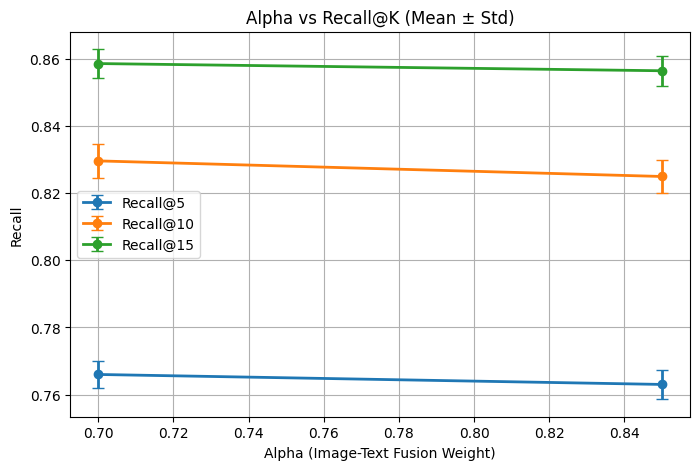

Saved: alpha_vs_recall_all.png


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# ---- LOAD SUMMARY ----
summary_df = pd.read_csv(f"{SAVE_DIR}/results_summary.csv")

# ---- PARSE ONLY RECALL METRICS ----
recall_data = {}

for _, row in summary_df.iterrows():
    metric = row['metric']  # e.g., alpha_0.7_R@10

    match = re.match(r'alpha_(\d+\.\d+)_R@(\d+)', metric)
    if not match:
        continue

    alpha = float(match.group(1))
    K     = int(match.group(2))  # 5, 10, 15

    if K not in recall_data:
        recall_data[K] = {}

    recall_data[K][alpha] = (row['mean'], row['std'])

# ---- SORT ALPHAS ----
alphas = sorted(list({a for d in recall_data.values() for a in d.keys()}))

# ---- PLOT ----
plt.figure(figsize=(8, 5))

for K in sorted(recall_data.keys()):
    means = [recall_data[K][a][0] for a in alphas]
    stds  = [recall_data[K][a][1] for a in alphas]

    plt.errorbar(
        alphas, means, yerr=stds,
        marker='o', capsize=4, linewidth=2,
        label=f'Recall@{K}'
    )

plt.xlabel('Alpha (Image-Text Fusion Weight)')
plt.ylabel('Recall')
plt.title('Alpha vs Recall@K (Mean ± Std)')
plt.legend()
plt.grid(True)

plt.savefig(f"{SAVE_DIR}/alpha_vs_recall_all.png", dpi=120)
plt.show()

print("Saved: alpha_vs_recall_all.png")

In [16]:
# ---- SAVE HISTORY ----
with open(f'{SAVE_DIR}/history_all_seeds.json', 'w') as f:
    json.dump(history_all, f, indent=4)


zip_path = f'{SAVE_DIR}/condition_c_multiseed.zip'

IMPORTANT_FILES = [

    "gallery_caps.json",
    "query_caps.json",

    "gallery_ids.json",
    "query_ids.json",

    "gallery_fused.npy",
    "query_fused.npy",

    "gallery_embs_crop.npy",
    "query_embs_crop.npy",

    "gallery_text_embs.npy",
    "query_text_embs.npy",

    "results_summary.csv",
    "results_per_seed.csv",

    "alpha_vs_recall_all.png",

    "best_clip_seed2023008.pt"
]

with zipfile.ZipFile(zip_path, 'w') as z:
    for fname in IMPORTANT_FILES:
        path = f'{SAVE_DIR}/{fname}'
        if os.path.exists(path):
            z.write(path, fname)

print("Zip created successfully.")

Zip created successfully.
